# Inhibitory modulation via Schur complement and perturbation analysis

This notebook investigates how inhibitory routing modulates stability in the signed, directed, weighted `mij` network.

Matrix convention used here:

- raw CSV rows are sources
- raw CSV columns are receivers
- analysis matrix is transposed to `M[receiver, source]`
- block names are written as source -> receiver: `EE`, `EI`, `IE`, `II`

Every section is shown side-by-side for two matrix variants:

- `with_self`: diagonal/self connections are retained
- `no_self`: the diagonal is zeroed before normalization

The default normalization is spectral-radius normalization to `0.85`. That means a baseline dominant eigenvalue of `0.85` is not a measured raw value; it is the chosen normalized reference point for each variant.

## Notebook role in the analysis sequence

**Role:** Mechanistic E/I modulation analysis.

**Inputs:**
- `matrices/mij_matrix.csv`
- `matrices/mij_netlist.csv`

**Outputs:**
- `outputs/inhibitory_schur_modulation/` tables and figures.

**What this notebook adds:**
- Partitions the network into E/I blocks.
- Uses Schur complements to estimate effective excitatory dynamics under inhibitory feedback.
- Tests block-removal perturbations, motif enrichment, Neumann-chain effects, and disinhibitory source rankings.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
    HAS_PLOTS = True
except ImportError:
    HAS_PLOTS = False
    print("Plotting libraries are not installed in this environment; table analyses will still run.")

from inhibitory_schur_modulation_script import (
    block_view,
    load_mij_data,
    run_side_by_side_analysis,
    save_side_by_side_outputs,
)

OUTPUT_DIR = Path("outputs/inhibitory_schur_modulation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_RHO = 1
ALPHA = 0.85
N_NULL = 250

## Load, orient, and normalize

The loader uses `matrices/mij_netlist.csv` to recover E/I labels, then falls back to row-sign inference only if metadata is missing. Each side of the comparison is normalized independently to the target spectral radius.

In [2]:
data = load_mij_data("matrices/mij_matrix.csv", "matrices/mij_netlist.csv")
results = run_side_by_side_analysis(
    data,
    normalization="spectral_radius",
    target=TARGET_RHO,
    alpha=ALPHA,
    n_null=N_NULL,
)

print(f"cells: {len(data.labels)}")
print(f"excitatory: {len(data.excitatory)} | inhibitory: {len(data.inhibitory)}")
print(f"normalization target spectral radius: {TARGET_RHO}")
results["normalization"]

cells: 85
excitatory: 32 | inhibitory: 53
normalization target spectral radius: 1


,method,target,scale,spectral_radius,spectral_abscissa,dominant_eigenvalue,dominant_real,dominant_imag,variant
0,spectral_radius,1,0.000038,1.0,1.0,1.0+0.0j,1.0,0.0,with_self
1,spectral_radius,1,0.000067,1.0,1.0,1.0+0.0j,1.0,0.0,no_self


In [3]:
INHIBITORY_FONT_COLOR = "#c1121f"
INHIBITORY_CELLS = set(data.inhibitory)
CELLTYPE_COLUMNS = [
    "cell",
    "node",
    "inhibitory_cell",
    "I_middle",
    "I_first",
    "I_second",
    "E_source",
    "E_receiver",
]


def is_inhibitory_celltype(value):
    return str(value) in INHIBITORY_CELLS


def style_inhibitory_celltypes(df, columns=None):
    """Render inhibitory cell-type names in red in notebook tables."""
    display_df = df.copy()
    if columns is None:
        columns = [col for col in CELLTYPE_COLUMNS if col in display_df.columns]
    else:
        columns = [col for col in columns if col in display_df.columns]

    def color_value(value):
        if is_inhibitory_celltype(value):
            return f"color: {INHIBITORY_FONT_COLOR}; font-weight: 700"
        return ""

    if not columns:
        return display_df
    styler = display_df.style
    # pandas 3.x renamed Styler.applymap() to Styler.map().
    if hasattr(styler, "map"):
        return styler.map(color_value, subset=columns)
    return styler.applymap(color_value, subset=columns)


def color_inhibitory_ticklabels(ax):
    """Color tick labels red when they are, or contain, inhibitory cell-type names."""
    for tick in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        text = tick.get_text()
        if text in INHIBITORY_CELLS or any(cell in text for cell in INHIBITORY_CELLS):
            tick.set_color(INHIBITORY_FONT_COLOR)
            tick.set_fontweight("bold")
    return ax


In [4]:
block_rows = []
for variant, payload in results["variants"].items():
    for name, block in block_view(payload["M"], data.ei).items():
        block_rows.append({
            "variant": variant,
            "block": name,
            "shape": str(block.shape),
            "nonzero": int(np.count_nonzero(block)),
            "positive": int(np.count_nonzero(block > 0)),
            "negative": int(np.count_nonzero(block < 0)),
            "fro_norm": np.linalg.norm(block, "fro"),
        })
pd.DataFrame(block_rows)

,variant,block,shape,nonzero,positive,negative,fro_norm
0,with_self,EE,"(32, 32)",382,382,0,5.171595
1,with_self,EI,"(53, 32)",352,352,0,81.078433
2,with_self,IE,"(32, 53)",171,0,171,0.088920
3,with_self,II,"(53, 53)",736,0,736,0.423299
4,no_self,EE,"(32, 32)",355,355,0,9.042052
5,no_self,EI,"(53, 32)",352,352,0,143.236198
6,no_self,IE,"(32, 53)",171,0,171,0.157090
7,no_self,II,"(53, 53)",692,0,692,0.625358


## Perturbation: remove EE, EI, IE, or II

This table compares the exact dominant eigenvalue change after zeroing each block with a first-order eigenvalue perturbation estimate.

Interpretation cue: if removing a block increases the dominant real part, that block was stabilizing relative to that variant's normalized baseline. If removing it decreases the dominant real part, that block was destabilizing or amplifying.

In [5]:
perturbation = results["perturbation"]
perturbation.sort_values(["removed_block", "variant"])

,variant,removed_block,block_meaning,dominant_real_before,dominant_real_after,delta_dominant_real,spectral_radius_before,spectral_radius_after,delta_spectral_radius,first_order_delta_real,first_order_delta_imag
4,no_self,EE,E source -> E receiver,1.0,0.116951,-0.883049,1.0,0.645704,-0.354296,-1.377895,0.0
0,with_self,EE,E source -> E receiver,1.0,0.074330,-0.925670,1.0,0.367008,-0.632992,-1.080015,0.0
7,no_self,EI,E source -> I receiver,1.0,1.171643,0.171643,1.0,1.171643,0.171643,0.195510,0.0
3,with_self,EI,E source -> I receiver,1.0,1.041928,0.041928,1.0,1.041928,0.041928,0.043133,0.0
6,no_self,IE,I source -> E receiver,1.0,1.171643,0.171643,1.0,1.171643,0.171643,0.195510,0.0
2,with_self,IE,I source -> E receiver,1.0,1.041928,0.041928,1.0,1.041928,0.041928,0.043133,0.0
5,no_self,II,I source -> I receiver,1.0,0.985519,-0.014481,1.0,0.985519,-0.014481,-0.013124,0.0
1,with_self,II,I source -> I receiver,1.0,0.992526,-0.007474,1.0,0.992526,-0.007474,-0.006251,0.0


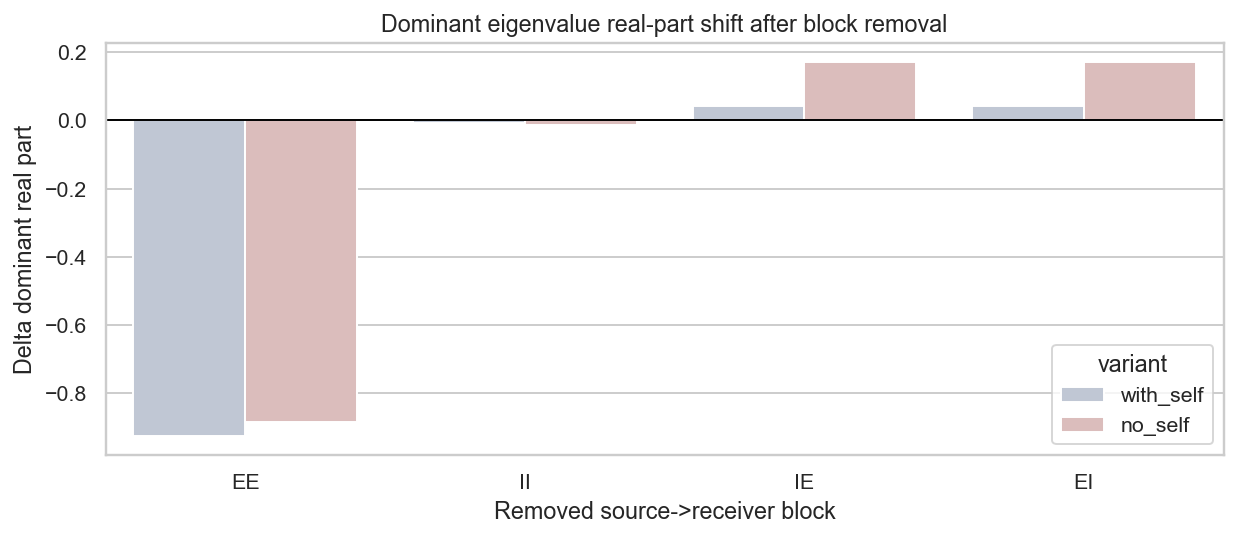

In [6]:
if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(9, 4), dpi=140)
    sns.barplot(data=perturbation, x="removed_block", y="delta_dominant_real", hue="variant", ax=ax, palette="vlag")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Dominant eigenvalue real-part shift after block removal")
    ax.set_xlabel("Removed source->receiver block")
    ax.set_ylabel("Delta dominant real part")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "block_removal_delta_dominant_real_by_variant.png", bbox_inches="tight")
    plt.show()
else:
    perturbation[["variant", "removed_block", "dominant_real_before", "dominant_real_after", "delta_dominant_real"]]

## Schur complement: eliminate inhibitory nodes

The inhibitory Schur complement is

`M_eff_E(z) = M_EE + M_EI @ inv(z I - M_II) @ M_IE`

where `z` defaults to the dominant eigenvalue of the full network variant. The feedback term is the part of E dynamics mediated by inhibitory cells, including all chained I-I paths inside the resolvent.

In [7]:
schur_summary = results["schur_summary"]
schur_summary

,variant,component,z_real,z_imag,rho_MII_over_z,spectral_radius,spectral_abscissa,dominant_eigenvalue,dominant_real,dominant_imag
0,with_self,M_EE,1.0,0.0,0.182206,1.041928,1.041928,1.041928+0.000000j,1.041928,0.0
1,with_self,inhibitory_feedback,1.0,0.0,0.182206,0.116285,0.006103,0.006103+0.000000j,0.006103,0.0
2,with_self,M_eff_E,1.0,0.0,0.182206,1.000000,1.000000,1.000000+0.000000j,1.000000,0.0
3,no_self,M_EE,1.0,0.0,0.136907,1.171643,1.171643,1.171643+0.000000j,1.171643,0.0
4,no_self,inhibitory_feedback,1.0,0.0,0.136907,0.365358,0.018307,0.018307+0.000000j,0.018307,0.0
5,no_self,M_eff_E,1.0,0.0,0.136907,1.000000,1.000000,1.000000+0.000000j,1.000000,0.0


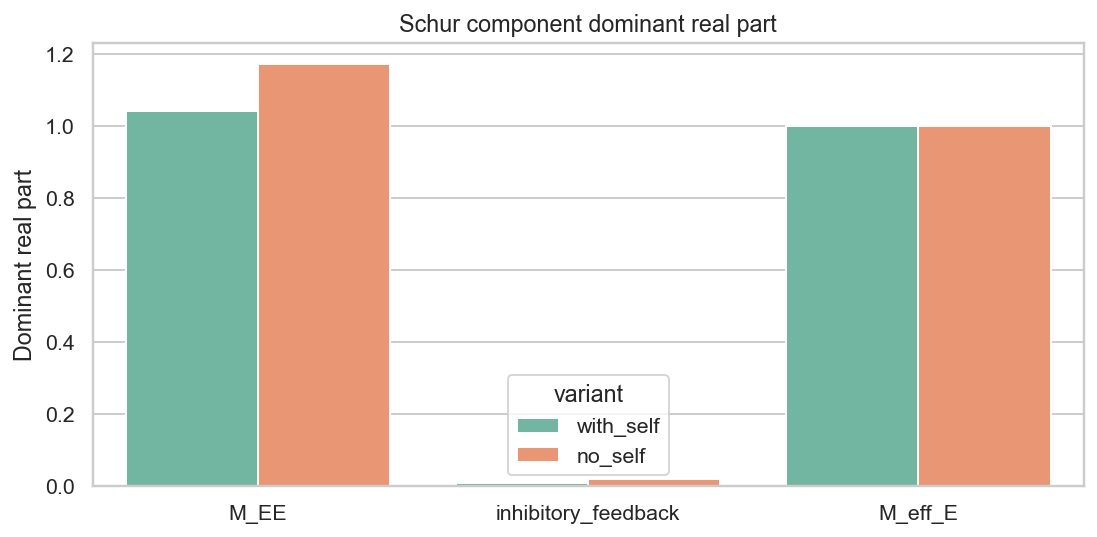

In [8]:
if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(8, 4), dpi=140)
    sns.barplot(data=schur_summary, x="component", y="dominant_real", hue="variant", ax=ax, palette="Set2")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title("Schur component dominant real part")
    ax.set_xlabel("")
    ax.set_ylabel("Dominant real part")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "schur_summary_by_variant.png", bbox_inches="tight")
    plt.show()
else:
    schur_summary[["variant", "component", "dominant_real", "spectral_radius", "rho_MII_over_z"]]

## Enrichment: excite all inhibitory or all excitatory cells

The response uses the stable discrete resolvent `(I - alpha M)^-1 u`. Positive E responses after inhibitory excitation are candidate disinhibitory effects; large I responses identify inhibitory relays.

In [9]:
print("Top response to exciting all inhibitory cells")
display(style_inhibitory_celltypes(results["response_I"]))
print("Top response to exciting all excitatory cells")
display(style_inhibitory_celltypes(results["response_E"]))


Top response to exciting all inhibitory cells


,variant,cell,ei,response,abs_response,source_population
0,with_self,CA1 Trilaminar,i,-1.726118,1.726118,I
1,with_self,CA1 Perforant Path Associated QuadD,i,-1.066989,1.066989,I
2,with_self,DG Neurogliaform,i,0.997098,0.997098,I
3,with_self,CA3 Trilaminar,i,0.994873,0.994873,I
4,with_self,DG MOPP,i,0.994739,0.994739,I
5,with_self,CA3 Spiny Lucidum,i,0.994349,0.994349,I
6,with_self,CA1 Neurogliaform Projecting,i,0.987656,0.987656,I
7,with_self,CA1 Oriens Bistratified,i,0.977761,0.977761,I
8,with_self,CA3 Horizontal Axo Axonic,i,0.977010,0.977010,I
9,with_self,DG HIPP,i,0.964260,0.964260,I


Top response to exciting all excitatory cells


,variant,cell,ei,response,abs_response,source_population
0,with_self,CA1 Trilaminar,i,149.204925,149.204925,E
1,with_self,MEC LIII Superficial Multipolar Interneuron,i,123.177187,123.177187,E
2,with_self,CA1 Perforant Path Associated QuadD,i,103.452088,103.452088,E
3,with_self,CA1 Perforant Path Associated,i,78.532579,78.532579,E
4,with_self,CA1 R Receiving Apical Targeting,i,51.765546,51.765546,E
5,with_self,DG Axo Axonic,i,50.866929,50.866929,E
6,with_self,DG AIPRIM,i,40.411084,40.411084,E
7,with_self,CA1 OR LM,i,36.223825,36.223825,E
8,with_self,CA1 LMR,i,30.815505,30.815505,E
9,with_self,CA1 Basket CCK+,i,30.696804,30.696804,E


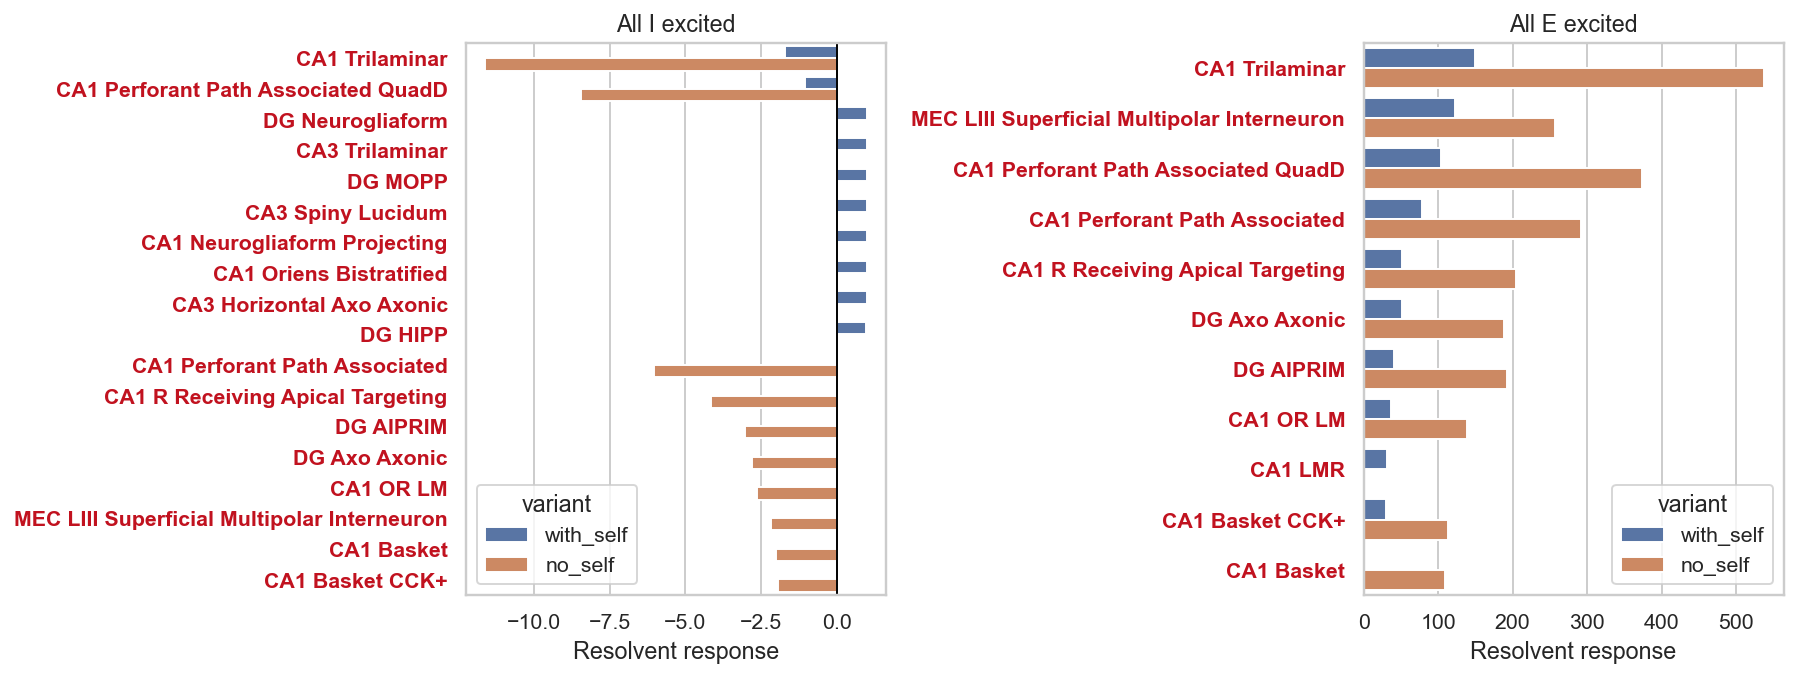

In [10]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=140)
    for ax, (title, frame) in zip(axes, [("All I excited", results["response_I"]), ("All E excited", results["response_E"])]):
        plot_frame = frame.groupby("variant", group_keys=False).head(10)
        sns.barplot(data=plot_frame, y="cell", x="response", hue="variant", ax=ax)
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(title)
        ax.set_xlabel("Resolvent response")
        ax.set_ylabel("")
        color_inhibitory_ticklabels(ax)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "population_excitation_responses_by_variant.png", bbox_inches="tight")
    plt.show()
else:
    display(style_inhibitory_celltypes(pd.concat([results["response_I"].head(10), results["response_E"].head(10)], ignore_index=True)))

## Motif enrichment and stability effect

The motif table now includes all-excitatory and all-inhibitory motif classes, along with convergent, divergent, chain, reciprocal, E-I-E, and E-I-I-E motifs.

The companion stability table asks the causal perturbation question: if we remove the edges participating in a motif class, how does the dominant eigenvalue change? This mirrors the logic of sections 7.1-7.4 in the reference notebook: define a condition, compute the network response, and summarize E/I population-level stability effects.


In [11]:
motif = results["motif"]
motif_stability = results["motif_stability"]

print("Motif enrichment/counts")
display(motif.sort_values(["motif", "variant"]))

print("Motif-removal dominant eigenvalue stability effects")
display(motif_stability.sort_values(["motif", "variant"])[[
    "variant",
    "motif",
    "motif_count",
    "edges_removed",
    "dominant_real_before",
    "dominant_real_after",
    "delta_dominant_real",
    "spectral_radius_before",
    "spectral_radius_after",
    "delta_spectral_radius",
]])

Motif enrichment/counts


,variant,motif,count,null_mean,null_sd,z_score,empirical_p_ge
10,no_self,E_to_I_to_I_to_E_loop,11255,1520.248,179.012156,54.380396,0.003984
0,with_self,E_to_I_to_I_to_E_loop,12468,1701.480,191.449726,56.236800,0.003984
16,no_self,all_excitatory_E_E_E_chains,4472,4472.000,NaN,NaN,1.000000
6,with_self,all_excitatory_E_E_E_chains,4472,4472.000,NaN,NaN,1.000000
19,no_self,all_excitatory_edges_E_to_E,355,355.000,NaN,NaN,1.000000
9,with_self,all_excitatory_edges_E_to_E,355,355.000,NaN,NaN,1.000000
15,no_self,all_inhibitory_I_I_I_chains,9553,9553.000,NaN,NaN,1.000000
5,with_self,all_inhibitory_I_I_I_chains,9553,9553.000,NaN,NaN,1.000000
17,no_self,all_inhibitory_edges_I_to_I,692,692.000,NaN,NaN,1.000000
7,with_self,all_inhibitory_edges_I_to_I,692,692.000,NaN,NaN,1.000000


Motif-removal dominant eigenvalue stability effects


,variant,motif,motif_count,edges_removed,dominant_real_before,dominant_real_after,delta_dominant_real,spectral_radius_before,spectral_radius_after,delta_spectral_radius
10,no_self,E_I_E_inhibitory_feedback,1341,515,1.0,1.171643,0.171643,1.0,1.171643,0.171643
5,with_self,E_I_E_inhibitory_feedback,1341,515,1.0,1.041928,0.041928,1.0,1.041928,0.041928
11,no_self,E_I_I_E_disinhibitory_feedback,11255,1159,1.0,1.171643,0.171643,1.0,1.171643,0.171643
4,with_self,E_I_I_E_disinhibitory_feedback,12468,1202,1.0,1.041928,0.041928,1.0,1.041928,0.041928
7,no_self,all_excitatory_E_E_E_chains,4472,355,1.0,0.116951,-0.883049,1.0,0.645704,-0.354296
1,with_self,all_excitatory_E_E_E_chains,4472,355,1.0,0.662927,-0.337073,1.0,0.662927,-0.337073
6,no_self,all_excitatory_edges_E_to_E,355,355,1.0,0.116951,-0.883049,1.0,0.645704,-0.354296
0,with_self,all_excitatory_edges_E_to_E,355,355,1.0,0.662927,-0.337073,1.0,0.662927,-0.337073
9,no_self,all_inhibitory_I_I_I_chains,9553,692,1.0,0.985519,-0.014481,1.0,0.985519,-0.014481
3,with_self,all_inhibitory_I_I_I_chains,9553,692,1.0,0.999186,-0.000814,1.0,0.999186,-0.000814


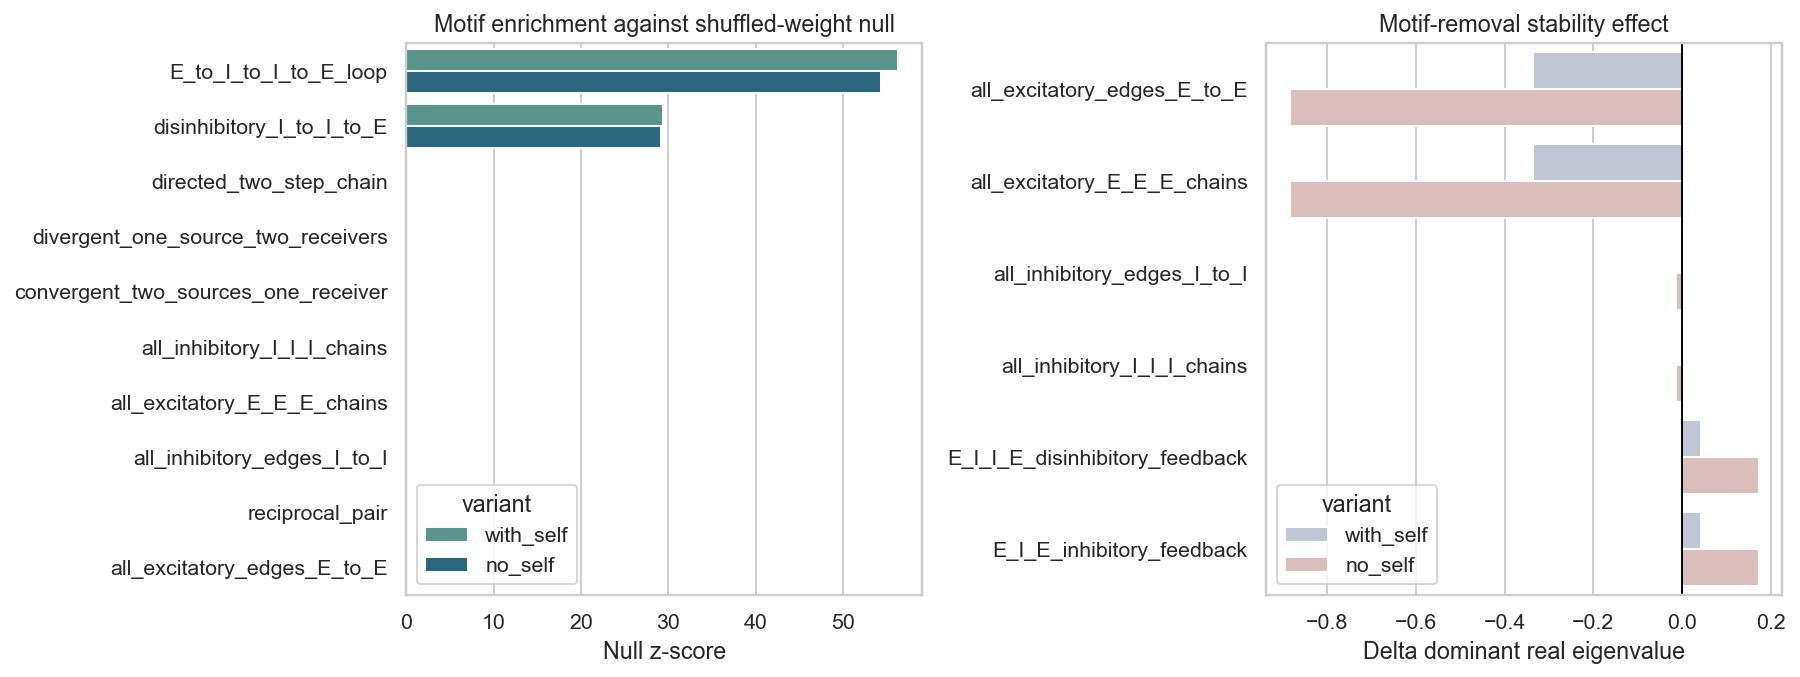

In [12]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=140)
    sns.barplot(data=motif, y="motif", x="z_score", hue="variant", ax=axes[0], palette="crest")
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_title("Motif enrichment against shuffled-weight null")
    axes[0].set_xlabel("Null z-score")
    axes[0].set_ylabel("")

    sns.barplot(data=motif_stability, y="motif", x="delta_dominant_real", hue="variant", ax=axes[1], palette="vlag")
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_title("Motif-removal stability effect")
    axes[1].set_xlabel("Delta dominant real eigenvalue")
    axes[1].set_ylabel("")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "motif_enrichment_and_stability_by_variant.png", bbox_inches="tight")
    plt.show()
else:
    motif_stability[["variant", "motif", "motif_count", "delta_dominant_real", "delta_spectral_radius"]]

## Neumann series for chained I-I effects

The Schur inhibitory feedback can be expanded as a Neumann series. Order `k` is the number of chained I-I edges inside the inhibitory block:

- `k = 0`: `E->I->E`
- `k = 1`: `E->I->I->E`
- `k = 2`: `E->I->I->I->E`
- `k = 3`: `E->I->I->I->I->E`

Model-selection rules:

- contribution decay: keep orders whose relative contribution is still large
- cumulative energy: keep enough orders to explain the requested cumulative energy
- spectral radius: stop when the spectral tail bound is small
- null significance: keep orders above the shuffled-II null model

In [13]:
neumann = results["neumann"]
print("Selected order by variant")
display(neumann["selected_orders"])
print("Selected order by rule")
display(neumann["selected_by_rule"])
neumann["selection_table"]

Selected order by variant


,variant,selected_order,alpha_rho_MII
0,with_self,2,0.154875
1,no_self,1,0.116371


Selected order by rule


,variant,rule,selected_order
0,with_self,contribution_decay,1
1,with_self,cumulative_energy,0
2,with_self,spectral_radius,2
3,with_self,null_significance,12
4,no_self,contribution_decay,1
5,no_self,cumulative_energy,0
6,no_self,spectral_radius,1
7,no_self,null_significance,0


,variant,ii_chain_order,motif_length,fro_norm,signed_sum,positive_sum,negative_sum,max_abs,spectral_bound,relative_contribution,cumulative_energy,passes_decay_rule,passes_cumulative_energy_rule,passes_spectral_radius_rule,null_mean_fro,null_sd_fro,null_z,passes_null_significance_rule
0,with_self,0,E->I->E,2.234204e+00,-5.574129e+00,0.000000e+00,-5.574129e+00,2.135653e+00,1.000000e+00,9.557886e-01,0.955789,True,False,True,2.234204e+00,4.894781e-15,0.997998,False
1,with_self,1,E->I->I->E,9.093412e-02,4.585259e-01,4.585259e-01,0.000000e+00,4.456406e-02,1.548748e-01,3.890145e-02,0.994690,True,False,True,8.559056e-02,5.132055e-02,0.104121,False
2,with_self,2,E->I->I->I->E,1.060087e-02,-5.372051e-02,0.000000e+00,-5.372051e-02,5.875143e-03,2.398619e-02,4.535034e-03,0.999225,False,False,True,6.540813e-03,4.643704e-03,0.874315,False
3,with_self,3,E->I->I->I->I->E,1.536676e-03,7.175063e-03,7.175063e-03,0.000000e+00,9.099114e-04,3.714856e-03,6.573871e-04,0.999882,False,False,False,5.482822e-04,4.444457e-04,2.223879,True
4,with_self,4,E->I->I->I->I->I->E,2.325226e-04,-1.011259e-03,0.000000e+00,-1.011259e-03,1.409223e-04,5.753374e-04,9.947274e-05,0.999982,False,False,False,4.888299e-05,5.297025e-05,3.466844,True
5,with_self,5,E->I->I->I->I->I->I->E,3.568547e-05,1.469741e-04,1.469741e-04,0.000000e+00,2.182531e-05,8.910524e-05,1.526618e-05,0.999997,False,False,False,4.474300e-06,6.373738e-06,4.896840,True
6,with_self,6,E->I->I->I->I->I->I->I->E,5.506304e-06,-2.180583e-05,0.000000e+00,-2.180583e-05,3.380190e-06,1.380015e-05,2.355587e-06,1.000000,False,False,False,4.269080e-07,7.778713e-07,6.529867,True
7,with_self,7,E->I->I->I->I->I->I->I->I->E,8.514547e-07,3.281165e-06,3.281165e-06,0.000000e+00,5.235061e-07,2.137295e-06,3.642508e-07,1.000000,False,False,False,4.244724e-08,9.525951e-08,8.492668,True
8,with_self,8,E->I->I->I->I->I->I->I->I->I->E,1.317793e-07,-4.984576e-07,0.000000e+00,-4.984576e-07,8.107787e-08,3.310131e-07,5.637494e-08,1.000000,False,False,False,4.389466e-09,1.173299e-08,10.857406,True
9,with_self,9,E->I->I->I->I->I->I->I->I->I->I->E,2.040311e-08,7.620921e-08,7.620921e-08,0.000000e+00,1.255692e-08,5.126558e-08,8.728415e-09,1.000000,False,False,False,4.717459e-10,1.453215e-09,13.715363,True


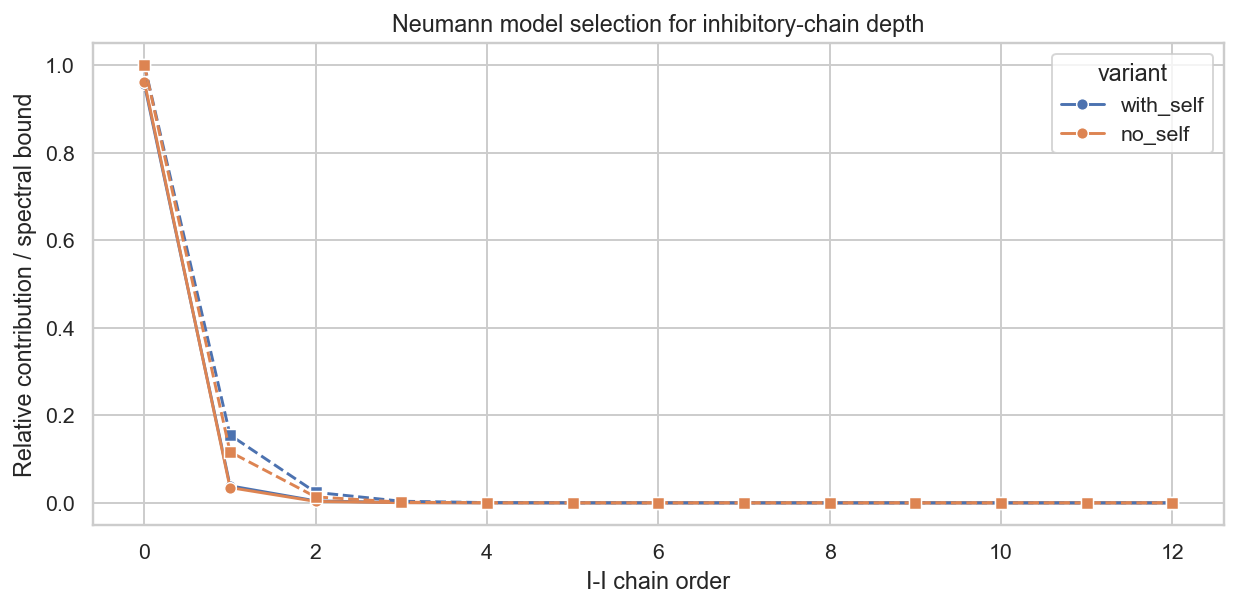

In [14]:
selection_table = neumann["selection_table"]
if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(9, 4.5), dpi=140)
    sns.lineplot(data=selection_table, x="ii_chain_order", y="relative_contribution", hue="variant", marker="o", ax=ax)
    sns.lineplot(data=selection_table, x="ii_chain_order", y="spectral_bound", hue="variant", marker="s", linestyle="--", ax=ax, legend=False)
    ax.set_xlabel("I-I chain order")
    ax.set_ylabel("Relative contribution / spectral bound")
    ax.set_title("Neumann model selection for inhibitory-chain depth")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "neumann_ii_model_selection_by_variant.png", bbox_inches="tight")
    plt.show()
else:
    selection_table[["variant", "ii_chain_order", "relative_contribution", "cumulative_energy", "spectral_bound", "null_z"]]

## Who carries stabilizing disinhibition?

This ranking scores inhibitory cells by their I->E strength, E->I recruitment, and participation in the selected I-I chain order. These are the candidate cell classes to inspect as stabilizing disinhibitory relays.

In [15]:
disinhibitors = results["disinhibitors"]
display(style_inhibitory_celltypes(disinhibitors))


,variant,inhibitory_cell,ii_chain_order,score,I_to_E_abs,E_to_I_abs,II_chain_participation,positive_disinhibitory_drive_to_E
0,with_self,CA1 Perforant Path Associated,2,2.757514,0.074158,35.941334,0.006571,0.000000
1,with_self,MEC LIII Superficial Multipolar Interneuron,2,1.542057,0.063164,22.015366,0.060751,0.000000
2,with_self,DG AIPRIM,2,0.488685,0.030743,14.034395,0.057300,0.000000
3,with_self,CA1 Basket CCK+,2,0.221641,0.012803,15.642121,0.040258,0.000000
4,with_self,CA1 Back Projection,2,0.178475,0.019161,8.070744,0.026882,0.000000
5,with_self,CA1 Trilaminar,2,0.138568,0.002254,59.727639,0.012404,0.000000
6,with_self,CA1 Basket,2,0.134904,0.007600,16.256293,0.028678,0.000000
7,with_self,MEC LIII Superficial Trilayered Interneuron,2,0.108962,0.043587,1.464200,0.014473,0.000000
8,with_self,CA2 Wide Arbor Basket,2,0.087356,0.021495,2.923777,0.035760,0.000000
9,with_self,DG Total Molecular Layer,2,0.078883,0.021369,2.609431,0.022726,0.000000


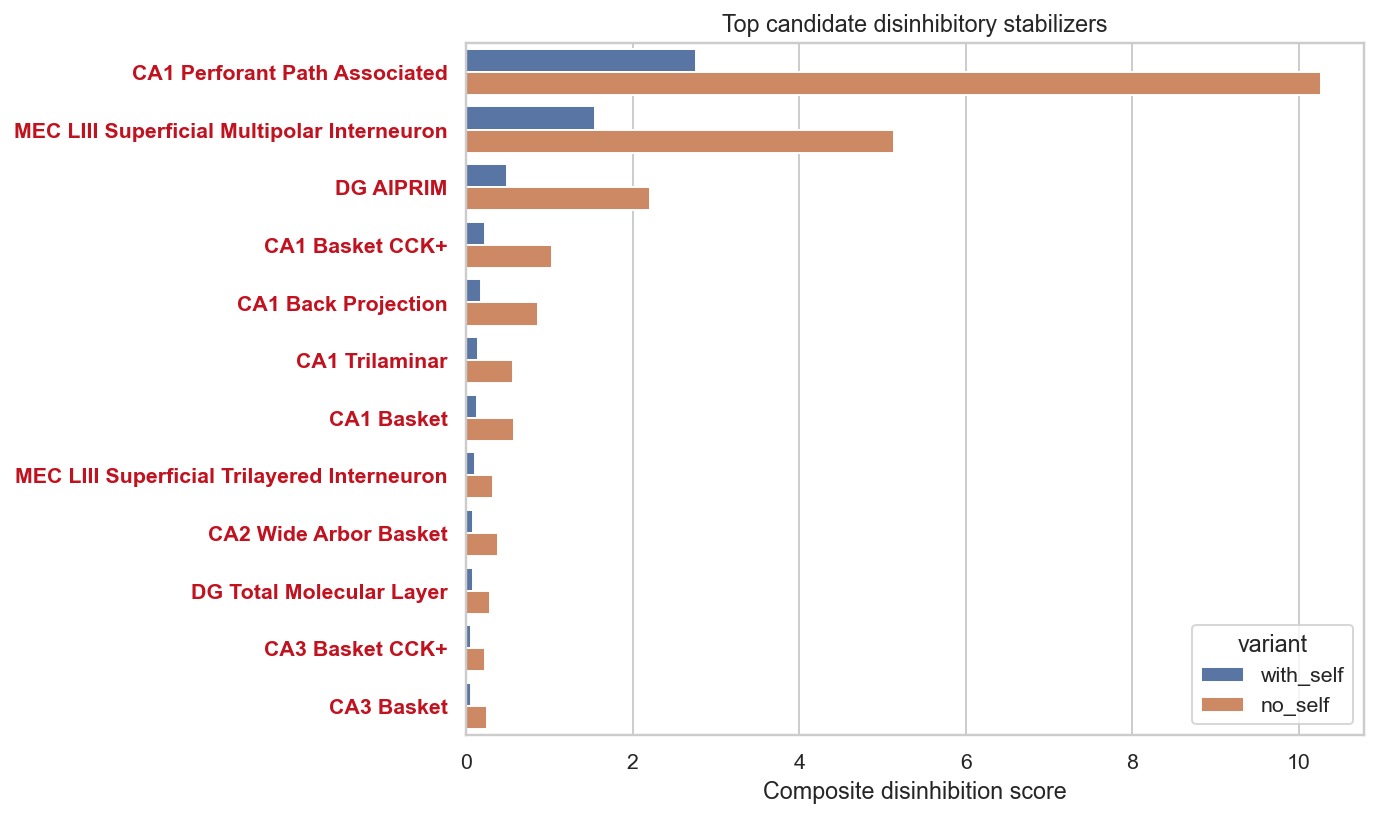

In [16]:
if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
    plot_frame = disinhibitors.groupby("variant", group_keys=False).head(12)
    sns.barplot(data=plot_frame, y="inhibitory_cell", x="score", hue="variant", ax=ax)
    ax.set_title("Top candidate disinhibitory stabilizers")
    ax.set_xlabel("Composite disinhibition score")
    ax.set_ylabel("")
    color_inhibitory_ticklabels(ax)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "top_disinhibitory_sources_by_variant.png", bbox_inches="tight")
    plt.show()
else:
    display(style_inhibitory_celltypes(disinhibitors.groupby("variant", group_keys=False).head(12)))

## Enumerate E-I-E and E-I-I-E configurations

These tables list the strongest explicit path configurations. `E-I-E` is a two-hop inhibitory route. `E-I-I-E` is the shortest disinhibitory route, with two inhibitory edges producing a positive E-to-E contribution.


In [17]:
paths = results["paths"]
print("Top E-I-E configurations")
display(style_inhibitory_celltypes(paths["EIE"]))
print("Top E-I-I-E disinhibitory configurations")
display(style_inhibitory_celltypes(paths["EIIE"]))


Top E-I-E configurations


,variant,motif,E_source,I_middle,E_receiver,E_to_I,I_to_E,signed_contribution,abs_contribution
0,with_self,E-I-E,CA3c Pyramidal,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,29.516807,-0.072207,-2.131309,2.131309
1,with_self,E-I-E,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Bipolar Complex Pyramidal,15.570332,-0.015336,-0.238782,0.238782
2,with_self,E-I-E,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Complex Pyramidal,15.570332,-0.014715,-0.229117,0.229117
3,with_self,E-I-E,CA2 Pyramidal,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,2.246937,-0.072207,-0.162244,0.162244
4,with_self,E-I-E,EC LIII Pyramidal Stellate,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,2.215315,-0.072207,-0.159960,0.159960
5,with_self,E-I-E,CA3c Pyramidal,CA1 Basket CCK+,CA1 Pyramidal,13.314090,-0.011930,-0.158835,0.158835
6,with_self,E-I-E,CA3 Pyramidal,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,1.744236,-0.072207,-0.125945,0.125945
7,with_self,E-I-E,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LII III Pyramidal Multiform,15.570332,-0.007965,-0.124023,0.124023
8,with_self,E-I-E,DG Granule,DG AIPRIM,DG Hilar Ectopic Granule,8.554853,-0.012064,-0.103205,0.103205
9,with_self,E-I-E,CA3c Pyramidal,CA1 Basket,CA1 Pyramidal,13.448626,-0.007188,-0.096669,0.096669


Top E-I-I-E disinhibitory configurations


,variant,motif,E_source,I_first,I_second,E_receiver,E_to_I,I_to_I,I_to_E,signed_contribution,abs_contribution
0,with_self,E-I-I-E,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Multipolar Interneuron,MEC LIII Bipolar Complex Pyramidal,15.570332,-0.178994,-0.015336,0.042741,0.042741
1,with_self,E-I-I-E,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Multipolar Interneuron,MEC LIII Complex Pyramidal,15.570332,-0.178994,-0.014715,0.041010,0.041010
2,with_self,E-I-I-E,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Multipolar Interneuron,MEC LII III Pyramidal Multiform,15.570332,-0.178994,-0.007965,0.022199,0.022199
3,with_self,E-I-I-E,CA3c Pyramidal,CA1 Perforant Path Associated,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,29.516807,-0.010380,-0.072207,0.022122,0.022122
4,with_self,E-I-I-E,CA3 Pyramidal,CA1 Trilaminar,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,46.823973,-0.004605,-0.072207,0.015570,0.015570
5,with_self,E-I-I-E,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Multipolar Interneuron,EC LIII Stellate,15.570332,-0.178994,-0.004829,0.013459,0.013459
6,with_self,E-I-I-E,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Multipolar Interneuron,MEC LII Stellate,15.570332,-0.178994,-0.004088,0.011393,0.011393
7,with_self,E-I-I-E,DG Granule,DG AIPRIM,DG AIPRIM,DG Hilar Ectopic Granule,8.554853,-0.104514,-0.012064,0.010786,0.010786
8,with_self,E-I-I-E,CA3c Pyramidal,CA1 R Receiving Apical Targeting,CA1 Perforant Path Associated,SUB CA1 Projecting Pyramidal,20.022728,-0.005726,-0.072207,0.008278,0.008278
9,with_self,E-I-I-E,DG Granule,DG AIPRIM,DG AIPRIM,DG Mossy,8.554853,-0.104514,-0.009182,0.008210,0.008210


C:\Users\ranic\AppData\Local\Temp\ipykernel_41124\1783642997.py:16: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


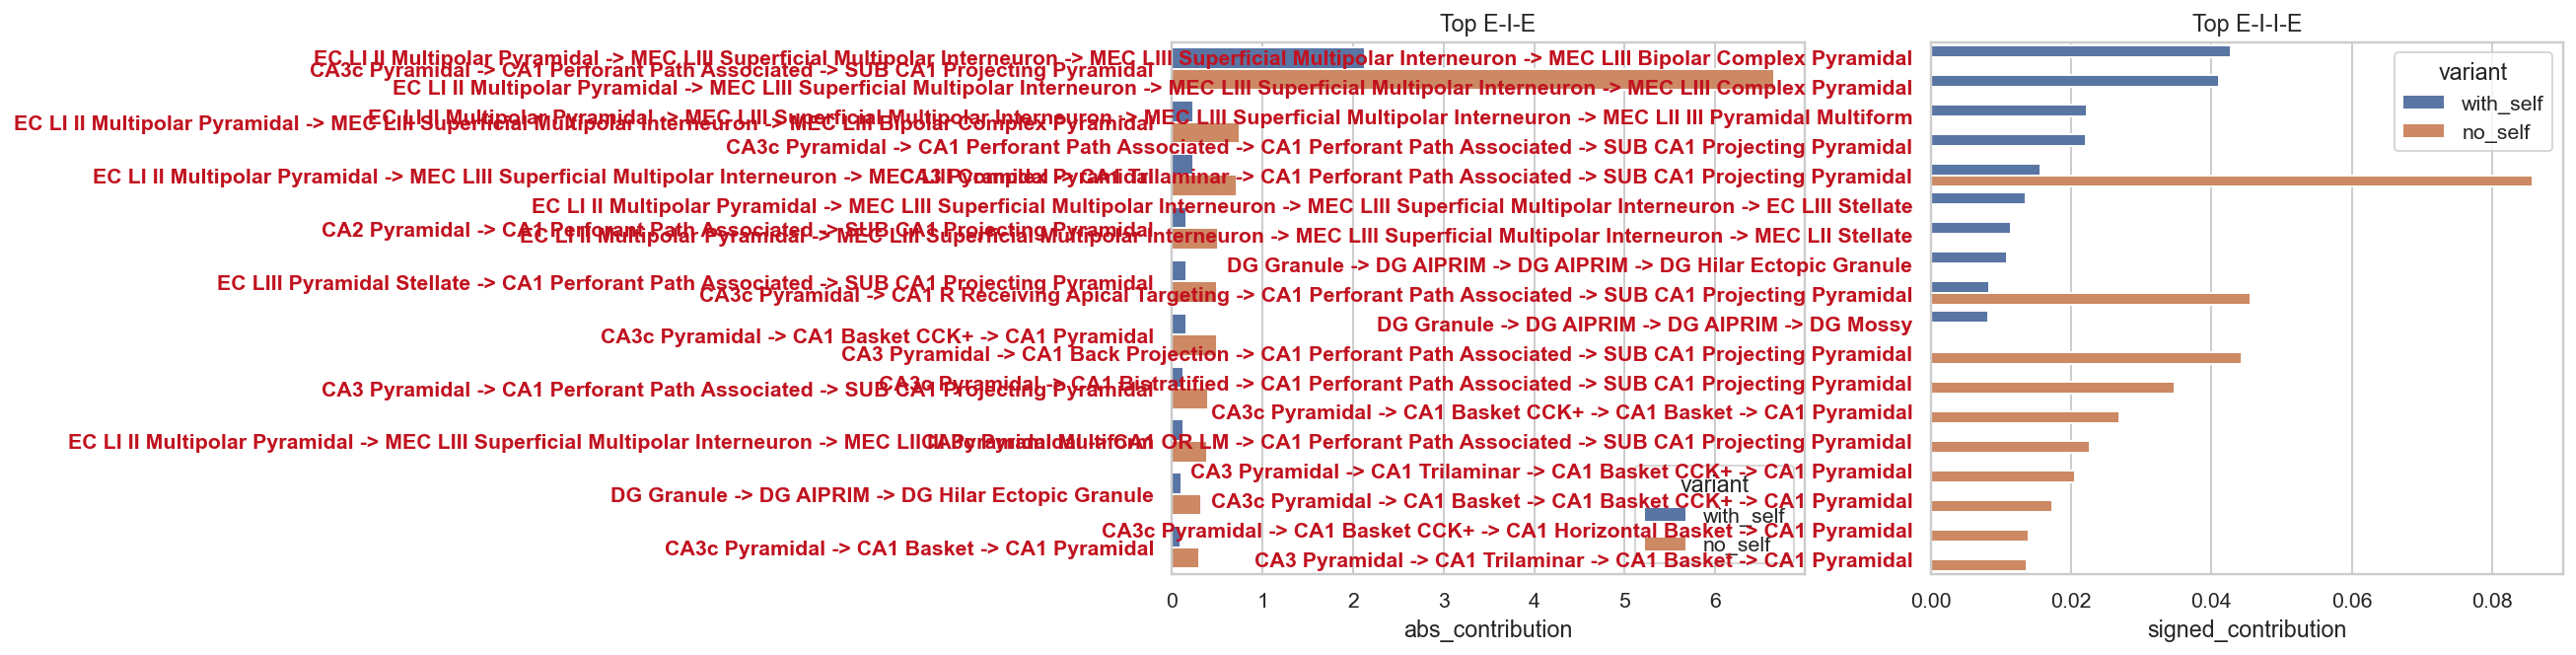

In [18]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=140)
    for ax, title, frame, xcol in [
        (axes[0], "Top E-I-E", paths["EIE"].groupby("variant", group_keys=False).head(10), "abs_contribution"),
        (axes[1], "Top E-I-I-E", paths["EIIE"].groupby("variant", group_keys=False).head(10), "signed_contribution"),
    ]:
        plot_frame = frame.copy()
        plot_frame["configuration"] = plot_frame.apply(
            lambda r: f"{r['E_source']} -> {r.get('I_middle', r.get('I_first'))} -> {r.get('I_second', '')} -> {r['E_receiver']}".replace(" ->  -> ", " -> "),
            axis=1,
        )
        sns.barplot(data=plot_frame, y="configuration", x=xcol, hue="variant", ax=ax)
        ax.set_title(title)
        ax.set_ylabel("")
        color_inhibitory_ticklabels(ax)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "top_path_configurations_by_variant.png", bbox_inches="tight")
    plt.show()
else:
    display(style_inhibitory_celltypes(paths["EIE"].head(10)))


## Save tables

In [19]:
save_side_by_side_outputs(OUTPUT_DIR, results)
print(f"Saved side-by-side tables and figures to {OUTPUT_DIR.resolve()}")

Saved side-by-side tables and figures to C:\Users\ranic\Documents\GitHub\schur_decomp\outputs\inhibitory_schur_modulation
